In [70]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import torch
from torch import nn, optim
from torch.autograd import Variable
from torch.utils.data import DataLoader
import torch.utils.data as Data
from torchvision import transforms, datasets
import calendar

In [87]:
def load_and_preprocess_data(file_path):
    """
    Parameters:
    file_path (str): 数据文件路径
    
    Returns:
    tuple: (特征数据DataFrame, 标签数据DataFrame)
    """
    # 读取数据
    df = pd.read_csv(file_path)
    
    # 数据清洗：删除特定列数据为空的所有行
    # 假设pm2.5是目标变量，不能为空
    df = df.dropna(subset=['pm2.5'])
    
    # 将NA字符串替换为NaN
    df = df.replace('NA', np.nan)
    
    # 处理数值型列
    numeric_columns = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col])
    
    # 删除仍有缺失值的行
    df = df.dropna()
    
    # 将日期时间组合成datetime列
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
    
    # 按日期排序
    df = df.sort_values('datetime')
    
    # 时间特征处理
    # 1. 年份偏移量编码
    base_year = df['year'].min()
    df['year_offset'] = df['year'] - base_year
    
    # 2. 周期性特征正余弦编码
    # 月份 (1-12)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # 日期 (1-28/29/30/31)
    df['days_in_month'] = df.apply(lambda row: calendar.monthrange(row['year'], row['month'])[1], axis=1)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / df['days_in_month'])
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / df['days_in_month'])
    
    # 小时 (0-23)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # 对风向特征进行One-Hot编码
    df_encoded = pd.get_dummies(df, columns=['cbwd'], prefix='cbwd', dtype=int)
    
    # 定义特征列 (包括pm2.5)
    feature_columns = [
        'pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir',
        'year_offset',
        'month_sin', 'month_cos',
        'day_sin', 'day_cos',
        'hour_sin', 'hour_cos'
    ]
    
    # 添加One-Hot编码的风向特征
    cbwd_columns = [col for col in df_encoded.columns if col.startswith('cbwd_')]
    feature_columns.extend(cbwd_columns)
    
    # 提取特征数据和标签数据
    data = df_encoded[feature_columns]  # 特征数据包括pm2.5
    label = df_encoded[['pm2.5']]       # 标签数据只有pm2.5
    
    print(f"基础年份: {base_year}")
    print(f"年份偏移范围: 0 - {df['year_offset'].max()}")
    print(f"One-Hot编码生成的风向列: {cbwd_columns}")
    print(f"总特征数: {len(feature_columns)}")
    # 打印特征数据和标签数据形状
    print(f"特征数据形状: {data.shape}")
    print(f"\n标签数据形状: {label.shape}")

    # 打印特征和标签数据的前5行
    print("特征数据前5行:")
    print(data.head())
    print("\n标签数据前5行:")
    print(label.head())
    
    return data, label

In [83]:
def normalization(data, label):
    """
    数据归一化
    只对需要归一化的特征进行归一化，避免对已经编码的特征重复处理
    """
    
    # 创建归一化容器实例，指定归一化到[-1, 1]区间
    mm_x = MinMaxScaler(feature_range=(-1, 1)) 
    mm_y = MinMaxScaler(feature_range=(-1, 1))
    
    # 定义需要归一化的数值型特征列
    numeric_features = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'year_offset']
    
    # 检查这些列是否在数据中存在
    existing_numeric_features = [col for col in numeric_features if col in data.columns]
    
    # 分离需要归一化的特征和不需要归一化的特征
    data_to_normalize = data[existing_numeric_features]
    data_normalized = mm_x.fit_transform(data_to_normalize)
    
    # 创建处理后的数据副本
    data_processed = data.copy()
    data_processed[existing_numeric_features] = data_normalized
    
    # 对标签数据进行归一化
    label_values = label.values
    label_normalized = mm_y.fit_transform(label_values)
    
    # 打印归一化信息
    print("需要归一化的特征列：", existing_numeric_features)
    print("归一化后的特征数据前5行：")
    print(data_processed.head())
    print("归一化后的标签数据前5行：")
    print(label_normalized[:5])
    
    # 返回归一化后的数据和标签，mm_y是为了在后续的反归一化步骤中使用
    return data_processed.values, label_normalized, mm_y

In [95]:
def split_windows(data, seq_length, target_column=0):
    """
    将时间序列数据转换为适合用于训练 LSTM 模型的输入和输出格式
    
    参数:
    data: DataFrame 或 二维numpy数组，归一化后的特征数据
    seq_length: int, 输入序列长度
    target_column: str 或 int, 目标变量列名或索引（对于numpy数组应使用int）
    """
    x = []
    y = []
    
    # 处理目标列索引
    if isinstance(target_column, str) and isinstance(data, pd.DataFrame):
        target_idx = data.columns.get_loc(target_column)
    elif isinstance(target_column, int):
        target_idx = target_column
    else:
        raise ValueError("target_column 必须是整数索引（用于numpy数组）或字符串列名（用于DataFrame）")
    
    for i in range(len(data) - seq_length - 1):
        _x = data[i:(i + seq_length), :]  
        _y = data[i + seq_length, target_idx]
        
        x.append(_x)
        y.append(_y)
    
    x, y = np.array(x), np.array(y)
    print('x.shape, y.shape=\n', x.shape, y.shape)
    return x, y

In [104]:
def split_data(x, y, split_ratio_train=0.8, split_ratio_val=0.1):
    """
    将输入的数据集分为训练集、验证集和测试集
    """
    train_size = int(len(y) * split_ratio_train)
    val_size = int(len(y) * split_ratio_val)
    
    x_train = torch.Tensor(x[0:train_size])
    y_train = torch.Tensor(y[0:train_size])
    x_val = torch.Tensor(x[train_size:train_size+val_size])
    y_val = torch.Tensor(y[train_size:train_size+val_size])
    x_test = torch.Tensor(x[train_size+val_size:len(x)])
    y_test = torch.Tensor(y[train_size+val_size:len(y)])
    
    return x_train, y_train, x_val, y_val, x_test, y_test

In [110]:
def data_generator(x_train, y_train, x_val, y_val, x_test, y_test, batch_size, n_iters):
    """
    生成数据加载器并计算训练轮数
    
    参数:
    x_train, y_train: 训练数据
    x_val, y_val: 验证数据
    x_test, y_test: 测试数据
    batch_size: 批次大小
    n_iters: 总迭代次数
    
    返回:
    train_loader, val_loader, test_loader: 数据加载器
    num_epochs: 计算得出的训练轮数
    """
    train_dataset = Data.TensorDataset(x_train, y_train)
    val_dataset = Data.TensorDataset(x_val, y_val)
    test_dataset = Data.TensorDataset(x_test, y_test)
    
    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    
    # 计算每个epoch的迭代次数
    train_batches_per_epoch = len(train_loader)
    
    # 根据总迭代次数计算训练轮数
    num_epochs = n_iters // train_batches_per_epoch
    
    print(f"每个epoch的batch数量: {train_batches_per_epoch}")
    print(f"总迭代次数: {n_iters}")
    print(f"训练轮数: {num_epochs}")
    
    return train_loader, val_loader, test_loader, num_epochs

In [115]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, batch_size, seq_length) -> None:
        super(Net, self).__init__()
        # 输入特征维度
        self.input_size = input_size
        # 隐藏层特征维度
        self.hidden_size = hidden_size
        # LSTM层数
        self.num_layers = num_layers
        # 输出特征维度
        self.output_size = output_size
        # 批次大小
        self.batch_size = batch_size
        # 序列长度
        self.seq_length = seq_length
        self.num_directions = 1  # 单向LSTM
        
        # LSTM层
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        # 全连接层
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # 获取批次大小（使用x的实际批次大小而不是self.batch_size）
        batch_size = x.size(0)
        
        # 初始化LSTM的隐藏状态和细胞状态为零
        # 使用torch.zeros而不是torch.randn
        h_0 = torch.zeros(self.num_directions * self.num_layers, batch_size, self.hidden_size, device=x.device)
        c_0 = torch.zeros(self.num_directions * self.num_layers, batch_size, self.hidden_size, device=x.device)
        
        # 输入 x 和隐藏状态 h_0, c_0 到 LSTM 层
        output, _ = self.lstm(x, (h_0, c_0))

        # 将 LSTM 的输出传递给全连接层，得到预测结果
        pred = self.fc(output)

        # 取最后一个时间步的输出作为预测结果
        pred = pred[:, -1, :]
        return pred

In [116]:
# 参数设置
seq_length=168 # 输入序列的时间步长，即模型在做预测时会用过去多少个时间点的数据
input_size=18 # 输入序列的特征维度
num_layers=3 # LSTM的层数
hidden_size=64 # LSTM层的隐藏单元数
batch_size=64  # 每次输入网络的数量批次大小
n_iters=5000 # 训练的迭代次数
lr=0.001 # 优化器的学习率
output_size=1 # 输出的维度
split_ratio=0.9 # 训练集和测试集的划分比例
path='zhangwenhao/PRSA_data_2010.1.1-2014.12.31.csv' # 数据文件路径
module=Net(input_size,hidden_size,num_layers,output_size,batch_size,seq_length)
criterion=torch.nn.MSELoss() #定义损失函数为均方误差损失
optimizer=torch.optim.Adam(module.parameters(),lr=lr) # 定义优化器为Adam优化器
print(module)

Net(
  (lstm): LSTM(18, 64, num_layers=3, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [117]:
# 数据预处理
data,label = load_and_preprocess_data(path)
# 数据归一化
data,label,mm_y=normalization(data,label)
# 数据切分
x,y=split_windows(data,seq_length)
# 数据集制作
x_train,y_train,x_val,y_val,x_test,y_test = split_data(x,y,split_ratio_train=0.8, split_ratio_val=0.1)
# 数据加载器生成和训练轮数计算
train_loader,val_loader,test_loader,num_epochs = data_generator(x_train,y_train,x_val,y_val,x_test,y_test,batch_size,n_iters)

基础年份: 2010
年份偏移范围: 0 - 4
One-Hot编码生成的风向列: ['cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']
总特征数: 18
特征数据形状: (41757, 18)

标签数据形状: (41757, 1)
特征数据前5行:
    pm2.5  DEWP  TEMP    PRES   Iws  Is  Ir  year_offset  month_sin  \
24  129.0   -16  -4.0  1020.0  1.79   0   0            0        0.5   
25  148.0   -15  -4.0  1020.0  2.68   0   0            0        0.5   
26  159.0   -11  -5.0  1021.0  3.57   0   0            0        0.5   
27  181.0    -7  -5.0  1022.0  5.36   1   0            0        0.5   
28  138.0    -7  -5.0  1022.0  6.25   2   0            0        0.5   

    month_cos   day_sin   day_cos  hour_sin  hour_cos  cbwd_NE  cbwd_NW  \
24   0.866025  0.394356  0.918958  0.000000  1.000000        0        0   
25   0.866025  0.394356  0.918958  0.258819  0.965926        0        0   
26   0.866025  0.394356  0.918958  0.500000  0.866025        0        0   
27   0.866025  0.394356  0.918958  0.707107  0.707107        0        0   
28   0.866025  0.394356  0.918958  0.866025  0.500000

In [ ]:
# 完整优化版本
module.train()
iteration = 0
best_val_loss = float('inf')
train_losses = []
val_losses = []

# 创建学习率调度器 (修复警告)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

for epoch in range(num_epochs):
    # 训练阶段
    epoch_train_loss = 0
    train_batches = 0
    
    for i, (batch_x, batch_y) in enumerate(train_loader):
        outputs = module(batch_x) 
        # 修复形状不匹配问题
        loss = criterion(outputs.squeeze(), batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(module.parameters(), max_norm=1.0)  # 梯度裁剪
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_batches += 1
        iteration += 1
        
        if iteration % 100 == 0:
            print("Iteration: %d, Loss: %1.5f" % (iteration, loss.item()))
    
    # 计算平均训练损失
    avg_train_loss = epoch_train_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # 验证阶段
    module.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = module(batch_x)
            # 修复形状不匹配问题
            val_loss += criterion(outputs.squeeze(), batch_y).item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")
    
    # 学习率调度
    scheduler.step(avg_val_loss)
    
    # 保存最佳模型
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(module.state_dict(), 'best_model.pth')
        print("Saved Best Model")
    
    module.train()

/root/miniconda3/envs/zhanjiang/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/root/miniconda3/envs/zhanjiang/lib/python3.10/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Iteration: 100, Loss: 0.02362
Iteration: 200, Loss: 0.02459
Iteration: 300, Loss: 0.02702
Iteration: 400, Loss: 0.01925
Iteration: 500, Loss: 0.03251
Epoch [1/9], Train Loss: 0.04875, Val Loss: 0.03943
Saved Best Model
Iteration: 600, Loss: 0.03185
Iteration: 700, Loss: 0.04268
Iteration: 800, Loss: 0.02188
Iteration: 900, Loss: 0.04734
Iteration: 1000, Loss: 0.03182
Epoch [2/9], Train Loss: 0.03421, Val Loss: 0.03961
Iteration: 1100, Loss: 0.02614
Iteration: 1200, Loss: 0.02624
Iteration: 1300, Loss: 0.03265
Iteration: 1400, Loss: 0.02927
Iteration: 1500, Loss: 0.05829
Epoch [3/9], Train Loss: 0.03436, Val Loss: 0.04022
Iteration: 1600, Loss: 0.04070
Iteration: 1700, Loss: 0.01991
Iteration: 1800, Loss: 0.03256
Iteration: 1900, Loss: 0.02593
Iteration: 2000, Loss: 0.02519
Epoch [4/9], Train Loss: 0.03424, Val Loss: 0.03965
Iteration: 2100, Loss: 0.02120
Iteration: 2200, Loss: 0.02778
Iteration: 2300, Loss: 0.03052
Iteration: 2400, Loss: 0.02272
Iteration: 2500, Loss: 0.03877
Epoch [5/

/tmp/ipykernel_24307/4175306827.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  module.load_state_dict(torch.load('best_model.pth'))



test set 评估结果:
MAE: 72.7319
RMSE: 90.5176


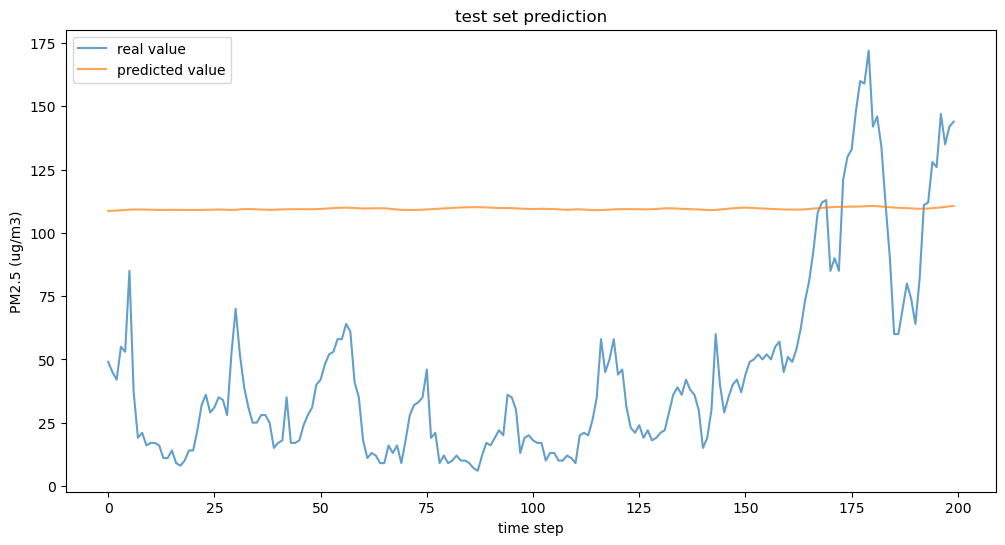


train set 评估结果:
MAE: 71.2968
RMSE: 91.4743


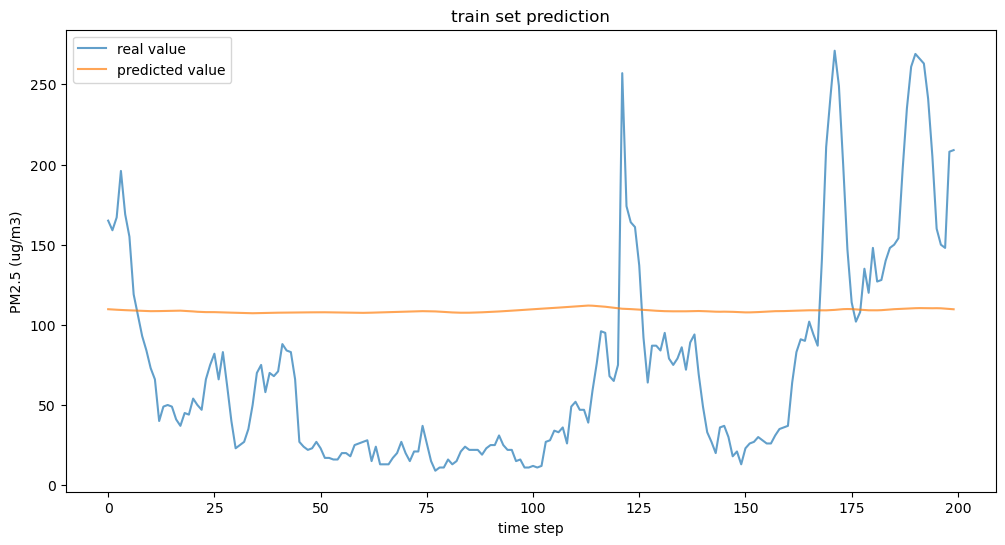

In [125]:
# 加载最佳模型
module.load_state_dict(torch.load('best_model.pth'))

def evaluate_model(x_data, y_data, mm_y_scaler, dataset_name="Dataset"):
    """
    评估模型性能
    """
    # 设置模型为评估模式
    module.eval()
    
    with torch.no_grad():
        # 进行预测
        predictions = module(x_data)
        
        # 转换为numpy数组
        predictions_np = predictions.numpy()
        y_true_np = y_data.numpy()
        
        # 重塑数据以进行逆归一化
        predictions_np = predictions_np.reshape(-1, 1)
        y_true_np = y_true_np.reshape(-1, 1)
        
        # 逆归一化
        predictions_original = mm_y_scaler.inverse_transform(predictions_np)
        y_true_original = mm_y_scaler.inverse_transform(y_true_np)
        
        # 计算评估指标
        mae = mean_absolute_error(y_true_original, predictions_original)
        rmse = np.sqrt(mean_squared_error(y_true_original, predictions_original))
        
        print(f"\n{dataset_name} 评估结果:")
        print(f"MAE: {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        
        # 绘制结果
        plt.figure(figsize=(12, 6))
        plt.plot(y_true_original[:200], label='real value', alpha=0.7)  # 只显示前200个点
        plt.plot(predictions_original[:200], label='predicted value', alpha=0.7)
        plt.legend()
        plt.title(f'{dataset_name} prediction')
        plt.xlabel('time step')
        plt.ylabel('PM2.5 (ug/m3)')
        plt.show()
        
        return predictions_original

# 评估测试集
test_predictions = evaluate_model(x_test, y_test, mm_y, "test set")

# 评估训练集
train_predictions = evaluate_model(x_train, y_train, mm_y, "train set")

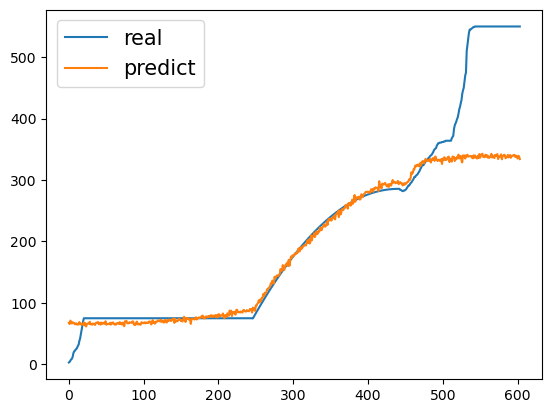

MAE/RMSE
34.822914123535156
75.00241858079478


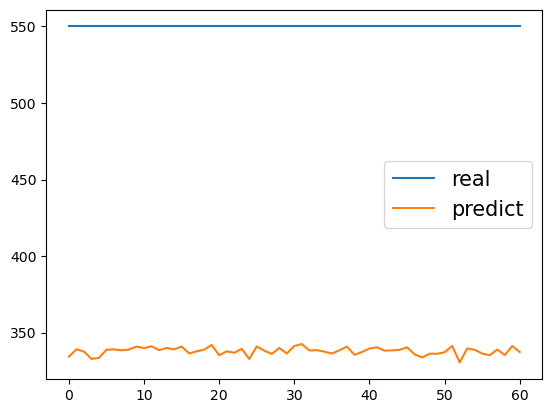

MAE/RMSE
211.98252868652344
211.99685839358563


In [22]:
def result(x_data, y_data):
  """
  评估和展示一个基于PyTorch的模型（在这里被称为moudle）对给定数据的预测性能
  Args:
    x_data: 输入数据
    y_data: 真实值
  Returns:
    无返回值，展示预测值和真实值的对比图以及评估指标
  """

  # 将模型设置为评估模式
  moudle.eval()

  # 预测值
  train_predict = moudle(x_data)

  # 将预测结果转换为NumPy数组，以便后续处理
  data_predict = train_predict.data.numpy()
  y_data_plot = y_data.data.numpy()

  #  重塑真实输出数据的形状，使其与预测数据的形状一致，便于后续的逆归一化处理
  y_data_plot = np.reshape(y_data_plot, (-1,1))  

  # 逆归一化处理
  data_predict = mm_y.inverse_transform(data_predict)
  y_data_plot = mm_y.inverse_transform(y_data_plot)

  # 绘制预测结果与真实结果
  plt.plot(y_data_plot)
  plt.plot(data_predict)
  plt.legend(('real', 'predict'),fontsize='15')
  plt.show()

  # 计算误差指标
  print('MAE/RMSE')
  print(mean_absolute_error(y_data_plot, data_predict))
  print(np.sqrt(mean_squared_error(y_data_plot, data_predict) ))

result(x_data, y_data)
result(x_test,y_test)